# Anomalous Sightings Archive 

## Imports & Variables 

In [1]:
import pandas as pd
import pygeohash as pgh
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import datetime
import sys
import os
import requests
import sqlite3
import time

from io import StringIO
from datetime import datetime, time 
from pathlib import Path
from tqdm.auto import tqdm 

root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_path not in sys.path:
    sys.path.append(root_path)

from python.kp_index import update_kp_data
from python.geo_location import create_geohashes
from python.geo_location import haversine_distance
from python.weather_api import get_weather
from python.weather_api import classify_weather



## Data Cleaning & Enrichment for US UAP Reports 1940 - 2014 

### Read the UAP Dataset into a Pandas Dataframe
- "../data/raw/uap_original_dataset.csv"
- a few rows in this large dataset have an extra column of irrelevent data
    - the fix: usecols=range(0, 11)

In [2]:
uap_df = pd.read_csv("../data/raw/uap_original_dataset.csv", usecols=range(0, 11), low_memory=False) 

uap_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88875 entries, 0 to 88874
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              88875 non-null  object 
 1   city                  88679 non-null  object 
 2   state                 81356 non-null  object 
 3   country               76314 non-null  object 
 4   shape                 85757 non-null  object 
 5   duration (seconds)    88873 non-null  object 
 6   duration (hours/min)  85772 non-null  object 
 7   comments              88749 non-null  object 
 8   date posted           88875 non-null  object 
 9   latitude              88875 non-null  object 
 10  longitude             88875 non-null  float64
dtypes: float64(1), object(10)
memory usage: 7.5+ MB


In [3]:
uap_df.head()

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611


In [4]:
# At least one row in the 'datetime' col contains an invalid 24:00 for the time
# AI Use: Grok assistance in fixing any entries with 24:00 in formating datetime

# Make a copy of the original column
col = uap_df['datetime'].astype(str)

# Handle 24:00 cases
mask_24 = col.str.contains('24:00', na=False)
col = col.str.replace('24:00', '00:00', regex=False)

# Convert to real datetime
uap_df['datetime'] = pd.to_datetime(col, format='%m/%d/%Y %H:%M', errors='coerce')

# Fix the date rollover for 24:00
uap_df.loc[mask_24, 'datetime'] = uap_df.loc[mask_24, 'datetime'] + pd.Timedelta(days=1)

# Create the columns 
uap_df['datetime_formatted'] = uap_df['datetime'].dt.strftime('%Y-%m-%d %H:%M')   # yyyy-mm-dd hh:mm
uap_df['full_date']           = uap_df['datetime'].dt.strftime('%Y-%m-%d')         # yyyy-mm-dd only

### Create Dataframe with Only US sightings 

In [5]:
us_uap_df = uap_df[uap_df["country"].str.lower() == "us"].copy()
us_uap_df.head()

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude,datetime_formatted,full_date
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111,1949-10-10 20:30,1949-10-10
3,1956-10-10 21:00:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833,1956-10-10 21:00,1956-10-10
4,1960-10-10 20:00:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611,1960-10-10 20:00,1960-10-10
5,1961-10-10 19:00:00,bristol,tn,us,sphere,300,5 minutes,My father is now 89 my brother 52 the girl wit...,4/27/2007,36.5950000,-82.188889,1961-10-10 19:00,1961-10-10
7,1965-10-10 23:45:00,norwalk,ct,us,disk,1200,20 minutes,A bright orange color changing to reddish colo...,10/2/1999,41.1175000,-73.408333,1965-10-10 23:45,1965-10-10


In [6]:
us_uap_after_1940_df = us_uap_df[
    us_uap_df["datetime"] >= '1940-01-01'
    
].copy()

us_uap_after_1940_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70276 entries, 0 to 88874
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              70276 non-null  datetime64[ns]
 1   city                  70276 non-null  object        
 2   state                 70276 non-null  object        
 3   country               70276 non-null  object        
 4   shape                 68047 non-null  object        
 5   duration (seconds)    70275 non-null  object        
 6   duration (hours/min)  68054 non-null  object        
 7   comments              70248 non-null  object        
 8   date posted           70276 non-null  object        
 9   latitude              70276 non-null  object        
 10  longitude             70276 non-null  float64       
 11  datetime_formatted    70276 non-null  object        
 12  full_date             70276 non-null  object        
dtypes: datetime64[ns](1),

### Find out how many null values remain

In [7]:
us_uap_after_1940_df.isnull().sum()

datetime                   0
city                       0
state                      0
country                    0
shape                   2229
duration (seconds)         1
duration (hours/min)    2222
comments                  28
date posted                0
latitude                   0
longitude                  0
datetime_formatted         0
full_date                  0
dtype: int64

### Fix null values in 'shape' column
- begin with finding unique values 

In [8]:
us_uap_after_1940_df['shape'].unique()

array(['cylinder', 'circle', 'light', 'sphere', 'disk', 'fireball',
       'unknown', 'oval', 'other', 'rectangle', 'chevron', 'formation',
       'triangle', 'cigar', nan, 'delta', 'changing', 'diamond', 'flash',
       'egg', 'teardrop', 'cone', 'cross', 'pyramid', 'round', 'flare',
       'hexagon', 'crescent', 'changed'], dtype=object)

### Assign 'shape' NA and Null values as 'unknown'

In [9]:
us_uap_after_1940_df['shape'] = us_uap_after_1940_df['shape'].fillna('unknown')
us_uap_after_1940_df.isnull().sum()

datetime                   0
city                       0
state                      0
country                    0
shape                      0
duration (seconds)         1
duration (hours/min)    2222
comments                  28
date posted                0
latitude                   0
longitude                  0
datetime_formatted         0
full_date                  0
dtype: int64

### fix durration (sec) null value - only one
- look at the row and decide to remove entry or fill in value .. 

In [10]:
us_uap_after_1940_df[us_uap_after_1940_df['duration (seconds)'].isnull()]

# airport sighting, unclear durration based on other values - drop row in place 
us_uap_after_1940_df.dropna(subset=['duration (seconds)'], inplace=True)

# check null value totals 
us_uap_after_1940_df.isnull().sum()

datetime                   0
city                       0
state                      0
country                    0
shape                      0
duration (seconds)         0
duration (hours/min)    2222
comments                  28
date posted                0
latitude                   0
longitude                  0
datetime_formatted         0
full_date                  0
dtype: int64

### remove 'duration hours / mins' 
- (null and wierd values + seconds column gives us duration and is more nomalized)

In [11]:
us_uap_after_1940_df.drop(columns = ['duration (hours/min)'], inplace=True)

# check null value totals 
us_uap_after_1940_df.isnull().sum()

datetime               0
city                   0
state                  0
country                0
shape                  0
duration (seconds)     0
comments              28
date posted            0
latitude               0
longitude              0
datetime_formatted     0
full_date              0
dtype: int64

### Fix null values in 'comments' column

In [12]:
# what do the rows look like? 
us_uap_after_1940_df[us_uap_after_1940_df['comments'].isnull()]

# fill with null comments with 'no comment' 
us_uap_after_1940_df['comments'] = us_uap_after_1940_df['comments'].fillna('no comments')

us_uap_after_1940_df.isnull().sum()

datetime              0
city                  0
state                 0
country               0
shape                 0
duration (seconds)    0
comments              0
date posted           0
latitude              0
longitude             0
datetime_formatted    0
full_date             0
dtype: int64

### convert 'duration (seconds)' to int
- some entries have non-integer values in them
- use regex in conversion to remove non-integers 

In [13]:
us_uap_after_1940_df['duration (seconds)'] = us_uap_after_1940_df['duration (seconds)'].astype(str).str.replace(r'[^0-9.]', '', regex=True)
us_uap_after_1940_df['duration (seconds)'] = us_uap_after_1940_df['duration (seconds)'].astype(float)
us_uap_after_1940_df['duration (seconds)'] = us_uap_after_1940_df['duration (seconds)'].round(0)
us_uap_after_1940_df['duration (seconds)'] = us_uap_after_1940_df['duration (seconds)'].astype(int)
us_uap_after_1940_df.head()

,datetime,city,state,country,shape,duration (seconds),comments,date posted,latitude,longitude,datetime_formatted,full_date
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111,1949-10-10 20:30,1949-10-10
3,1956-10-10 21:00:00,edna,tx,us,circle,20,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833,1956-10-10 21:00,1956-10-10
4,1960-10-10 20:00:00,kaneohe,hi,us,light,900,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611,1960-10-10 20:00,1960-10-10
5,1961-10-10 19:00:00,bristol,tn,us,sphere,300,My father is now 89 my brother 52 the girl wit...,4/27/2007,36.5950000,-82.188889,1961-10-10 19:00,1961-10-10
7,1965-10-10 23:45:00,norwalk,ct,us,disk,1200,A bright orange color changing to reddish colo...,10/2/1999,41.1175000,-73.408333,1965-10-10 23:45,1965-10-10


### Convert latitude to float type (longitude is already a float)

In [14]:
us_uap_after_1940_df['latitude'] = us_uap_after_1940_df['latitude'].astype(float)

us_uap_after_1940_df.dtypes

datetime              datetime64[ns]
city                          object
state                         object
country                       object
shape                         object
duration (seconds)             int64
comments                      object
date posted                   object
latitude                     float64
longitude                    float64
datetime_formatted            object
full_date                     object
dtype: object

### Convert 'full_date' to datetime + create 'year' and 'month' column

In [15]:
us_uap_after_1940_df['full_date'] = pd.to_datetime(us_uap_after_1940_df['full_date'])

us_uap_after_1940_df['year'] = us_uap_after_1940_df['full_date'].astype(str).str[:4]
us_uap_after_1940_df['year'] = us_uap_after_1940_df['year'].astype(int)

us_uap_after_1940_df['month'] = us_uap_after_1940_df['full_date'].astype(str).str[5:7]
us_uap_after_1940_df['month'] = us_uap_after_1940_df['month'].astype(int)

us_uap_after_1940_df.head()
us_uap_after_1940_df.dtypes

datetime              datetime64[ns]
city                          object
state                         object
country                       object
shape                         object
duration (seconds)             int64
comments                      object
date posted                   object
latitude                     float64
longitude                    float64
datetime_formatted            object
full_date             datetime64[ns]
year                           int64
month                          int64
dtype: object

# Enrich data even more with a 'season' column
- create season_groups dictionary
- map to 'month' value in each row

In [16]:
season_groups = {
    '01': 'winter', 
    '02': 'winter', 
    '03': 'spring', 
    '04': 'spring', 
    '05': 'spring',
    '06': 'summer',
    '07': 'summer', 
    '08': 'summer',
    '09': 'fall', 
    '10': 'fall',
    '11': 'fall',
    '12': 'winter',
}

us_uap_after_1940_df['season'] = us_uap_after_1940_df['month'].astype(str).str.zfill(2).map(season_groups)

us_uap_after_1940_df.head()

,datetime,city,state,country,shape,duration (seconds),comments,date posted,latitude,longitude,datetime_formatted,full_date,year,month,season
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700,This event took place in early fall around 194...,4/27/2004,29.883056,-97.941111,1949-10-10 20:30,1949-10-10,1949,10,fall
3,1956-10-10 21:00:00,edna,tx,us,circle,20,My older brother and twin sister were leaving ...,1/17/2004,28.978333,-96.645833,1956-10-10 21:00,1956-10-10,1956,10,fall
4,1960-10-10 20:00:00,kaneohe,hi,us,light,900,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.418056,-157.803611,1960-10-10 20:00,1960-10-10,1960,10,fall
5,1961-10-10 19:00:00,bristol,tn,us,sphere,300,My father is now 89 my brother 52 the girl wit...,4/27/2007,36.595000,-82.188889,1961-10-10 19:00,1961-10-10,1961,10,fall
7,1965-10-10 23:45:00,norwalk,ct,us,disk,1200,A bright orange color changing to reddish colo...,10/2/1999,41.117500,-73.408333,1965-10-10 23:45,1965-10-10,1965,10,fall


### Add KP Index Data ('solar_kp_index', 'solar_ap_index' columns)
- Call update_kp_data function in module
- Read csv file into pandas df
- Ensure datetime is datetime 
- KP data is in UTZ and updated every 3 hours: for a given day, find the the data that matched to 9pm 21:00 US Central Time
- Create a 'full_date' column in the kp_9pm_us_cst_df to merge on.
- Merge to full_date to us uap sightings

In [17]:
update_kp_data()

   year  month  day  hour_start  hour_end  decimal_day_start  decimal_day_end  \
0  1932      1    1         0.0       1.5              0.000           0.0625   
1  1932      1    1         3.0       4.5              0.125           0.1875   
2  1932      1    1         6.0       7.5              0.250           0.3125   
3  1932      1    1         9.0      10.5              0.375           0.4375   
4  1932      1    1        12.0      13.5              0.500           0.5625   

      kp  ap  flag            datetime  
0  3.333  18     1 1932-01-01 00:00:00  
1  2.667  12     1 1932-01-01 03:00:00  
2  2.333   9     1 1932-01-01 06:00:00  
3  2.667  12     1 1932-01-01 09:00:00  
4  3.333  18     1 1932-01-01 12:00:00  


,year,month,day,hour_start,hour_end,decimal_day_start,decimal_day_end,kp,ap,flag,datetime
0,1932,1,1,0.0,1.5,0.000,0.0625,3.333,18,1,1932-01-01 00:00:00
1,1932,1,1,3.0,4.5,0.125,0.1875,2.667,12,1,1932-01-01 03:00:00
2,1932,1,1,6.0,7.5,0.250,0.3125,2.333,9,1,1932-01-01 06:00:00
3,1932,1,1,9.0,10.5,0.375,0.4375,2.667,12,1,1932-01-01 09:00:00
4,1932,1,1,12.0,13.5,0.500,0.5625,3.333,18,1,1932-01-01 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...
276328,2026,7,27,0.0,1.5,34541.000,34541.0625,1.333,5,0,2026-07-27 00:00:00
276329,2026,7,27,3.0,4.5,34541.125,34541.1875,0.667,3,0,2026-07-27 03:00:00
276330,2026,7,27,6.0,7.5,34541.250,34541.3125,1.333,5,0,2026-07-27 06:00:00
276331,2026,7,27,9.0,10.5,34541.375,34541.4375,0.667,3,0,2026-07-27 09:00:00


In [18]:
kp_df = pd.read_csv("../data/processed/kp_index.csv", usecols=('datetime', 'kp', 'ap'))
kp_df.head(20)

,kp,ap,datetime
0,3.333,18,1932-01-01 00:00:00
1,2.667,12,1932-01-01 03:00:00
2,2.333,9,1932-01-01 06:00:00
3,2.667,12,1932-01-01 09:00:00
4,3.333,18,1932-01-01 12:00:00
5,2.667,12,1932-01-01 15:00:00
6,3.333,18,1932-01-01 18:00:00
7,3.333,18,1932-01-01 21:00:00
8,3.667,22,1932-01-02 00:00:00
9,3.667,22,1932-01-02 03:00:00


In [19]:
# ensure datetime column is a datetime type
kp_df['datetime'] = pd.to_datetime(kp_df['datetime'])
kp_df.dtypes

kp                 float64
ap                   int64
datetime    datetime64[ns]
dtype: object

In [20]:
# kp table includes values in utz (5-6 hours ahead of most US timezones)
# most uap sightings in the US happen late in the evening / close 9:00pm or 21:00 
# 03:00:00 or 3am UTZ would be the best match for most sightings .. which is 9pm central standard time 

# only 03:00 utz (it will have the next day's date, so we would need to convert to US time zome)
target_time = time(3, 0, 0)

# Filter for exactly 03:00 UTC
kp_3am_utz_df = kp_df[kp_df['datetime'].dt.time == target_time].copy()

# Convert to US Central Standard Time (CST = UTC-6)
kp_9pm_us_cst_df = kp_3am_utz_df.copy()
kp_9pm_us_cst_df['datetime'] = kp_9pm_us_cst_df['datetime'] - pd.Timedelta(hours=6)

kp_9pm_us_cst_df.head()



,kp,ap,datetime
1,2.667,12,1931-12-31 21:00:00
9,3.667,22,1932-01-01 21:00:00
17,3.333,18,1932-01-02 21:00:00
25,0.333,2,1932-01-03 21:00:00
33,0.000,0,1932-01-04 21:00:00


In [21]:
# Create a 'full_date' column in the kp_9pm_us_cst_df to merge on

kp_9pm_us_cst_df['full_date'] = kp_9pm_us_cst_df['datetime'].dt.strftime('%Y-%m-%d')
kp_9pm_us_cst_df['full_date'] = pd.to_datetime(kp_9pm_us_cst_df['full_date'])
kp_9pm_us_cst_df.head()

,kp,ap,datetime,full_date
1,2.667,12,1931-12-31 21:00:00,1931-12-31
9,3.667,22,1932-01-01 21:00:00,1932-01-01
17,3.333,18,1932-01-02 21:00:00,1932-01-02
25,0.333,2,1932-01-03 21:00:00,1932-01-03
33,0.000,0,1932-01-04 21:00:00,1932-01-04


In [22]:
# Merge to full_date to us uap sightings

us_uap_after_1940_df = pd.merge(us_uap_after_1940_df, kp_9pm_us_cst_df[['full_date','kp', 'ap']], on='full_date', how='left')

us_uap_after_1940_df.head()

,datetime,city,state,country,shape,duration (seconds),comments,date posted,latitude,longitude,datetime_formatted,full_date,year,month,season,kp,ap
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700,This event took place in early fall around 194...,4/27/2004,29.883056,-97.941111,1949-10-10 20:30,1949-10-10,1949,10,fall,2.667,12
1,1956-10-10 21:00:00,edna,tx,us,circle,20,My older brother and twin sister were leaving ...,1/17/2004,28.978333,-96.645833,1956-10-10 21:00,1956-10-10,1956,10,fall,2.667,12
2,1960-10-10 20:00:00,kaneohe,hi,us,light,900,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.418056,-157.803611,1960-10-10 20:00,1960-10-10,1960,10,fall,3.667,22
3,1961-10-10 19:00:00,bristol,tn,us,sphere,300,My father is now 89 my brother 52 the girl wit...,4/27/2007,36.595000,-82.188889,1961-10-10 19:00,1961-10-10,1961,10,fall,1.667,6
4,1965-10-10 23:45:00,norwalk,ct,us,disk,1200,A bright orange color changing to reddish colo...,10/2/1999,41.117500,-73.408333,1965-10-10 23:45,1965-10-10,1965,10,fall,0.333,2


### Additional Cleanup
- create state_code column in uppercase to match bigfoot data and ERD
- rename columns to match ERD

In [23]:
# create state_code column in uppercase to match bigfoot data and ERD

us_uap_after_1940_df['state_code'] = us_uap_after_1940_df['state'].str.upper()

# rename to match ERD

us_uap_after_1940_df = us_uap_after_1940_df.rename(
    columns={
        'duration (seconds)': 'duration_secs',
        'kp': 'solar_kp_index', 
        'ap': 'solar_ap_index'
    }
)

### Group Shapes - Enrich Data with 'shape_group' column
- There are many unique 'shapes' reported, but many are similar in 'type'
    - example: 'fireball' and 'flash' are both 'light' types
- Create a shape_groups dictionary
    - Missing or unknown values will be grouped in the 'other' category 
- Map to 'shape' column 

In [24]:

# group shapes by types 

shape_groups = {
    'circle': 'round', 'sphere': 'round', 'disk': 'round', 
    'oval': 'round', 'round': 'round', 'crescent': 'round', 'dome': 'round',
    'egg': 'round', 'teardrop': 'round',
    
    'triangle': 'triangle', 'delta': 'triangle', 'chevron': 'triangle', 
    'pyramid': 'triangle', 'diamond': 'triangle',
    
    'cylinder': 'cigar', 'cigar': 'cigar',
    
    'light': 'light', 'fireball': 'light', 'flash': 'light', 'flare': 'light',
    
    'changing': 'changing', 'changed': 'changing', 'formation': 'changing', 'cone': 'changing',
    'cross': 'changing', 'hexagon': 'changing', 'rectangle': 'changing',
    
    'other': 'other', 
    'nan': 'other',
    'unknown': 'other',
    '': 'other'
}

us_uap_after_1940_df['shape_group'] = us_uap_after_1940_df['shape'].map(shape_groups)

us_uap_after_1940_df['shape_group'].value_counts()

shape_group
light       20796
round       20253
other       12139
triangle     8809
changing     5442
cigar        2836
Name: count, dtype: int64

### Check head and save to CSV in data/processed/ folder 

In [25]:
us_uap_after_1940_df.head()

,datetime,city,state,country,shape,duration_secs,comments,date posted,latitude,longitude,datetime_formatted,full_date,year,month,season,solar_kp_index,solar_ap_index,state_code,shape_group
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700,This event took place in early fall around 194...,4/27/2004,29.883056,-97.941111,1949-10-10 20:30,1949-10-10,1949,10,fall,2.667,12,TX,cigar
1,1956-10-10 21:00:00,edna,tx,us,circle,20,My older brother and twin sister were leaving ...,1/17/2004,28.978333,-96.645833,1956-10-10 21:00,1956-10-10,1956,10,fall,2.667,12,TX,round
2,1960-10-10 20:00:00,kaneohe,hi,us,light,900,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.418056,-157.803611,1960-10-10 20:00,1960-10-10,1960,10,fall,3.667,22,HI,light
3,1961-10-10 19:00:00,bristol,tn,us,sphere,300,My father is now 89 my brother 52 the girl wit...,4/27/2007,36.595000,-82.188889,1961-10-10 19:00,1961-10-10,1961,10,fall,1.667,6,TN,round
4,1965-10-10 23:45:00,norwalk,ct,us,disk,1200,A bright orange color changing to reddish colo...,10/2/1999,41.117500,-73.408333,1965-10-10 23:45,1965-10-10,1965,10,fall,0.333,2,CT,round


In [26]:
us_uap_after_1940_df.sort_values(by='datetime', ascending=True, inplace=True)

us_uap_after_1940_df['uap_id'] = range(1, len(us_uap_after_1940_df) +1)

In [27]:
# create_geohashes function imported from python.geo_location
# create columns for geohash_7, 6, 5 ( use later for plotting, maps, and proximity )

us_uap_after_1940_df[['geohash_7', 'geohash_6', 'geohash_5']] = us_uap_after_1940_df.apply(
    lambda row: create_geohashes(row['latitude'], row['longitude']),
    axis=1,
    result_type='expand'
)

In [28]:
# add rounded hour column
us_uap_after_1940_df['rounded_dt'] = us_uap_after_1940_df['datetime'].dt.round('h')
us_uap_after_1940_df['hour'] = us_uap_after_1940_df['rounded_dt'].dt.strftime('%H') 


In [29]:
# reorder all columns to match ERD
# remove irrelevent columns - 'country' & 'date_posted'
# write to csv 

us_uap_after_1940_df = us_uap_after_1940_df[[
    'uap_id', 'datetime', 'city', 'state_code', 'state', 'duration_secs',
     'latitude', 'longitude', 'geohash_5', 'geohash_6', 'geohash_7',
     'full_date', 'year', 'month', 'season',  'datetime_formatted', 'rounded_dt', 'hour', 
     'shape', 'shape_group', 'comments',
     'solar_kp_index', 'solar_ap_index',        
    ]]


In [30]:
us_uap_after_1940_df.columns

us_uap_after_1940_df.to_csv("../data/processed/us_uap_1940_v1.csv", index=False)

### Additional Enrichment Before Saving to Final

In [31]:
us_uap_after_1940_df.dtypes

uap_id                         int64
datetime              datetime64[ns]
city                          object
state_code                    object
state                         object
duration_secs                  int64
latitude                     float64
longitude                    float64
geohash_5                     object
geohash_6                     object
geohash_7                     object
full_date             datetime64[ns]
year                           int64
month                          int64
season                        object
datetime_formatted            object
rounded_dt            datetime64[ns]
hour                          object
shape                         object
shape_group                   object
comments                      object
solar_kp_index               float64
solar_ap_index                 int64
dtype: object

### Finished? Save to 'data/final/' folder 

In [32]:
us_uap_after_1940_df.to_csv("../data/final/uap_reports.csv", index=False)

## Data Cleaning & Enrichment for Bigfoot Dataset(s)

### Read the first Bigfoot Dataset 
- '../data/raw/bfro_locations.csv'

In [33]:
pd.set_option('display.max_columns', None) 

bigfoot_df = pd.read_csv('../data/raw/bfro_locations.csv', index_col=False)

bigfoot_df.shape
bigfoot_df.describe(include='all')
bigfoot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4250 entries, 0 to 4249
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   index           4250 non-null   int64  
 1   number          4250 non-null   int64  
 2   title           4250 non-null   object 
 3   classification  4250 non-null   object 
 4   timestamp       4250 non-null   object 
 5   latitude        4250 non-null   float64
 6   longitude       4250 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 232.6+ KB


In [34]:
bigfoot_df.isna().sum()

index             0
number            0
title             0
classification    0
timestamp         0
latitude          0
longitude         0
dtype: int64

### Rename 'number' to 'bf_id' 
- We will use this as the Primary Key later on
- Check datatypes 

In [35]:
bigfoot_df = bigfoot_df.rename(columns={"number": "bf_id"})
bigfoot_df.dtypes

index               int64
bf_id               int64
title              object
classification     object
timestamp          object
latitude          float64
longitude         float64
dtype: object

### Merge geohash data from the other bigfoot dataset 
- sample random entry to see if data matches
- rename 'number' to 'bf_id' in geohashed dataset
- merge on bf_id

In [36]:
bigfoot_df.loc[bigfoot_df['bf_id'] == 799]

,index,bf_id,title,classification,timestamp,latitude,longitude
13,13,799,Report 799: Person fishing recounts story of h...,Class A,1978-04-15T12:00:00Z,34.92855,-87.1105


In [37]:
# Read in geohashed dataset csv and ensure 799 is a match

bigfoot_geocoded_df = pd.read_csv('../data/raw/bfro_reports_geocoded.csv')
bigfoot_geocoded_df['number'] = bigfoot_geocoded_df['number'].astype(int)
bigfoot_geocoded_df.loc[bigfoot_geocoded_df['number'] == 799]

,index,observed,location_details,county,state,season,title,latitude,longitude,date,number,classification,geohash,temperature_high,temperature_mid,temperature_low,dew_point,humidity,cloud_cover,moon_phase,precip_intensity,precip_probability,precip_type,pressure,summary,uv_index,visibility,wind_bearing,wind_speed
1219,1219,"The main sighting, as I wish to refer to it he...",The main sighting report I leave here happened...,Limestone County,Alabama,Spring,Report 799: Person fishing recounts story of h...,34.92855,-87.1105,1978-04-15,799,Class A,dn4n9y81d1,76.72,59.2,41.68,42.34,0.55,0.56,0.26,0.0,0.0,NaN,1019.14,Mostly cloudy throughout the day.,5.0,9.91,40.0,2.63


In [38]:
# so, it looks like we will need to do a left join from the bigfoot_df to the bigfoot_geocoded_df ... bf_id = number
# We need the state and city and wx data from the geocoded - so we will go through with the merge

bigfoot_geocoded_df = bigfoot_geocoded_df.rename(columns={"number": "bf_id"})
combined_bigfoot_df = pd.merge(
    bigfoot_df, 
    bigfoot_geocoded_df[[
        'bf_id', 
        'date', 
        'season', 
        'state', 
        'geohash',  
        'temperature_mid', 
        'precip_type', 
        'dew_point', 
        'cloud_cover', 
        'moon_phase', 
        'observed']], 
        on='bf_id', 
        how='left'
    )

combined_bigfoot_df.head()

,index,bf_id,title,classification,timestamp,latitude,longitude,date,season,state,geohash,temperature_mid,precip_type,dew_point,cloud_cover,moon_phase,observed
0,0,637,Report 637: Campers' encounter just after dark...,Class A,2000-06-16T12:00:00Z,61.5000,-142.9000,2000-06-16,Summer,Alaska,bffmu5xrkw,NaN,rain,42.75,1.00,0.49,My hiking partner and I arrived late to the Ke...
1,1,2917,Report 2917: Family observes large biped from car,Class A,1995-05-15T12:00:00Z,55.1872,-132.7982,1995-05-15,Spring,Alaska,c1c9fne29x,48.595,rain,42.15,0.95,0.54,"I was going for a drive. I had 3 kids with me,..."
2,2,7963,Report 7963: Sasquatch walks past window of ho...,Class A,2004-02-09T12:00:00Z,55.2035,-132.8202,2004-02-09,Winter,Alaska,c1cd197r9n,43.490,rain,41.51,0.98,0.62,This incident happened last night just after 1...
3,3,9317,"Report 9317: Driver on Alcan Highway has noon,...",Class A,2004-06-18T12:00:00Z,62.9375,-141.5667,2004-06-18,Summer,Alaska,bg5q496m8b,70.275,NaN,43.18,0.33,0.03,"My daughter and I were traveling to Tok, Alask..."
4,4,13038,Report 13038: Snowmobiler has encounter in dee...,Class A,2004-02-15T12:00:00Z,61.0595,-149.7853,2004-02-15,Winter,Alaska,bdv7re99me,18.665,NaN,17.35,0.16,0.84,I and two of my friends were bored one night s...


In [39]:
combined_bigfoot_df.dtypes

index                int64
bf_id                int64
title               object
classification      object
timestamp           object
latitude           float64
longitude          float64
date                object
season              object
state               object
geohash             object
temperature_mid    float64
precip_type         object
dew_point          float64
cloud_cover        float64
moon_phase         float64
observed            object
dtype: object

In [40]:
# full_date(datetime), year(int), month(int), dat(int)

combined_bigfoot_df['full_date'] = pd.to_datetime(combined_bigfoot_df['date'], format='%Y-%m-%d', errors='coerce')


combined_bigfoot_df.head()

,index,bf_id,title,classification,timestamp,latitude,longitude,date,season,state,geohash,temperature_mid,precip_type,dew_point,cloud_cover,moon_phase,observed,full_date
0,0,637,Report 637: Campers' encounter just after dark...,Class A,2000-06-16T12:00:00Z,61.5000,-142.9000,2000-06-16,Summer,Alaska,bffmu5xrkw,NaN,rain,42.75,1.00,0.49,My hiking partner and I arrived late to the Ke...,2000-06-16
1,1,2917,Report 2917: Family observes large biped from car,Class A,1995-05-15T12:00:00Z,55.1872,-132.7982,1995-05-15,Spring,Alaska,c1c9fne29x,48.595,rain,42.15,0.95,0.54,"I was going for a drive. I had 3 kids with me,...",1995-05-15
2,2,7963,Report 7963: Sasquatch walks past window of ho...,Class A,2004-02-09T12:00:00Z,55.2035,-132.8202,2004-02-09,Winter,Alaska,c1cd197r9n,43.490,rain,41.51,0.98,0.62,This incident happened last night just after 1...,2004-02-09
3,3,9317,"Report 9317: Driver on Alcan Highway has noon,...",Class A,2004-06-18T12:00:00Z,62.9375,-141.5667,2004-06-18,Summer,Alaska,bg5q496m8b,70.275,NaN,43.18,0.33,0.03,"My daughter and I were traveling to Tok, Alask...",2004-06-18
4,4,13038,Report 13038: Snowmobiler has encounter in dee...,Class A,2004-02-15T12:00:00Z,61.0595,-149.7853,2004-02-15,Winter,Alaska,bdv7re99me,18.665,NaN,17.35,0.16,0.84,I and two of my friends were bored one night s...,2004-02-15


In [41]:
combined_bigfoot_df['full_date'].describe()

count                             4045
mean     1999-06-22 13:15:17.577255808
min                1869-11-10 00:00:00
25%                1990-09-15 00:00:00
50%                2003-11-16 00:00:00
75%                2009-08-16 00:00:00
max                2021-11-27 00:00:00
Name: full_date, dtype: object

In [42]:
combined_bigfoot_df = combined_bigfoot_df[combined_bigfoot_df['full_date'] > '1949']
combined_bigfoot_df['full_date'].describe()

count                             4033
mean     1999-09-03 02:36:01.963798528
min                1949-08-15 00:00:00
25%                1990-10-31 00:00:00
50%                2003-11-29 00:00:00
75%                2009-08-25 00:00:00
max                2021-11-27 00:00:00
Name: full_date, dtype: object

In [43]:
combined_bigfoot_df.isna().sum()

index                 0
bf_id                 0
title                 0
classification        0
timestamp             0
latitude              0
longitude             0
date                  0
season                0
state                 0
geohash               0
temperature_mid     847
precip_type        2310
dew_point           660
cloud_cover         949
moon_phase          637
observed             31
full_date             0
dtype: int64

In [44]:
# dataset has many NA values - missing weather data
    # solution : 2 tables 
    # reports and locations (main)
    # create seperate bigfoot_weather_df - with weather data
# bf_id is primary key

bigfoot_weather_df = combined_bigfoot_df.copy()

# drop all NA values (mostly weather data)
bigfoot_weather_df.dropna(inplace=True)

bigfoot_weather_df.isna().sum()



index              0
bf_id              0
title              0
classification     0
timestamp          0
latitude           0
longitude          0
date               0
season             0
state              0
geohash            0
temperature_mid    0
precip_type        0
dew_point          0
cloud_cover        0
moon_phase         0
observed           0
full_date          0
dtype: int64

In [45]:
# include only weather related and essential columns (like bf_id) in bigfoot_weather_df
# leave out 'precip_type' - not accurate

bigfoot_weather_df = bigfoot_weather_df[[
    'bf_id', 'full_date', 'latitude', 'longitude', 'season', 
    'temperature_mid', 'dew_point', 'cloud_cover', 'moon_phase'
]]

# verify

bigfoot_weather_df.dtypes 

bf_id                       int64
full_date          datetime64[ns]
latitude                  float64
longitude                 float64
season                     object
temperature_mid           float64
dew_point                 float64
cloud_cover               float64
moon_phase                float64
dtype: object

In [46]:
# round the F temp down to 1 decimal point
bigfoot_weather_df['temperature_mid'] = round(bigfoot_weather_df['temperature_mid'], 1)

# raname to temperature_f for consistency
bigfoot_weather_df.rename(columns={"temperature_mid" : "temperature_f"}, inplace=True)

# round down to 1 decimal 
bigfoot_weather_df['dew_point'] = round(bigfoot_weather_df['dew_point'], 1)

# sort by bf_id
bigfoot_weather_df = bigfoot_weather_df.drop_duplicates(subset=['bf_id'])

bigfoot_weather_df = bigfoot_weather_df.sort_values(by='bf_id', ascending=True)

# check head
bigfoot_weather_df.head()

,bf_id,full_date,latitude,longitude,season,temperature_f,dew_point,cloud_cover,moon_phase
2125,76,2001-08-11,36.37139,-92.25139,Summer,80.0,69.1,0.33,0.73
3824,77,1983-09-01,46.98333,-121.09220,Fall,53.3,45.6,0.68,0.80
3494,85,2000-06-08,45.03255,-122.48080,Spring,53.6,49.6,0.98,0.23
3495,96,1978-06-25,43.78270,-123.95990,Summer,58.6,52.1,0.83,0.68
2194,97,1992-10-01,41.72278,-120.32920,Winter,58.3,32.0,0.18,0.19


In [47]:
# cloud_cover * 100 to normalize and match UAP cloud cover

bigfoot_weather_df['cloud_cover'] = bigfoot_weather_df['cloud_cover'] * 100 

In [48]:
# write to csv in processed folder

bigfoot_weather_df.to_csv("../data/processed/bigfoot_weather_processed.csv", index=False)

In [49]:
# create bigfoot_weather_final_df for final enrichment

bigfoot_weather_final_df = pd.read_csv("../data/processed/bigfoot_weather_processed.csv")

In [50]:
bigfoot_weather_df.isna().sum()

bf_id            0
full_date        0
latitude         0
longitude        0
season           0
temperature_f    0
dew_point        0
cloud_cover      0
moon_phase       0
dtype: int64

In [51]:
bigfoot_weather_final_df.dtypes

bf_id              int64
full_date         object
latitude         float64
longitude        float64
season            object
temperature_f    float64
dew_point        float64
cloud_cover      float64
moon_phase       float64
dtype: object

In [52]:
# 'season' column contains Unknown values 

bigfoot_weather_final_df['season'].unique()

array(['Summer', 'Fall', 'Spring', 'Winter', 'Unknown'], dtype=object)

In [53]:
bigfoot_weather_final_df['full_date'] = pd.to_datetime(bigfoot_weather_final_df['full_date'], format='%Y-%m-%d', errors='coerce')
bigfoot_weather_final_df['month'] = bigfoot_weather_final_df['full_date'].dt.month.astype(int)

season_groups = {
    '01': 'winter', 
    '02': 'winter', 
    '03': 'spring', 
    '04': 'spring', 
    '05': 'spring',
    '06': 'summer',
    '07': 'summer', 
    '08': 'summer',
    '09': 'fall', 
    '10': 'fall',
    '11': 'fall',
    '12': 'winter',
}

bigfoot_weather_final_df['season'] = bigfoot_weather_final_df['month'].astype(str).str.zfill(2).map(season_groups)

bigfoot_weather_final_df['season'].unique()


array(['summer', 'fall', 'spring', 'winter'], dtype=object)

In [54]:
bigfoot_weather_final_df = bigfoot_weather_final_df[[
    'bf_id', 'full_date', 'month', 'latitude', 'longitude', 
    'season', 'temperature_f', 'dew_point', 'cloud_cover', 'moon_phase']]

bigfoot_weather_final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   bf_id          1416 non-null   int64         
 1   full_date      1416 non-null   datetime64[ns]
 2   month          1416 non-null   int64         
 3   latitude       1416 non-null   float64       
 4   longitude      1416 non-null   float64       
 5   season         1416 non-null   object        
 6   temperature_f  1416 non-null   float64       
 7   dew_point      1416 non-null   float64       
 8   cloud_cover    1416 non-null   float64       
 9   moon_phase     1416 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 110.8+ KB


In [55]:
# write to csv in final folder

bigfoot_weather_final_df.to_csv("../data/final/bigfoot_weather.csv", index=False)

In [56]:
# drop weather columns from combined_bigfoot ( since we have a bigfoot weather table )

combined_bigfoot_df.drop(columns=['precip_type', 'temperature_mid', 'dew_point', 'cloud_cover', 'moon_phase'], inplace=True)
combined_bigfoot_df.isna().sum()

index              0
bf_id              0
title              0
classification     0
timestamp          0
latitude           0
longitude          0
date               0
season             0
state              0
geohash            0
observed          31
full_date          0
dtype: int64

In [57]:
combined_bigfoot_df.dtypes

index                      int64
bf_id                      int64
title                     object
classification            object
timestamp                 object
latitude                 float64
longitude                float64
date                      object
season                    object
state                     object
geohash                   object
observed                  object
full_date         datetime64[ns]
dtype: object

In [58]:
combined_bigfoot_df.head()

,index,bf_id,title,classification,timestamp,latitude,longitude,date,season,state,geohash,observed,full_date
0,0,637,Report 637: Campers' encounter just after dark...,Class A,2000-06-16T12:00:00Z,61.5000,-142.9000,2000-06-16,Summer,Alaska,bffmu5xrkw,My hiking partner and I arrived late to the Ke...,2000-06-16
1,1,2917,Report 2917: Family observes large biped from car,Class A,1995-05-15T12:00:00Z,55.1872,-132.7982,1995-05-15,Spring,Alaska,c1c9fne29x,"I was going for a drive. I had 3 kids with me,...",1995-05-15
2,2,7963,Report 7963: Sasquatch walks past window of ho...,Class A,2004-02-09T12:00:00Z,55.2035,-132.8202,2004-02-09,Winter,Alaska,c1cd197r9n,This incident happened last night just after 1...,2004-02-09
3,3,9317,"Report 9317: Driver on Alcan Highway has noon,...",Class A,2004-06-18T12:00:00Z,62.9375,-141.5667,2004-06-18,Summer,Alaska,bg5q496m8b,"My daughter and I were traveling to Tok, Alask...",2004-06-18
4,4,13038,Report 13038: Snowmobiler has encounter in dee...,Class A,2004-02-15T12:00:00Z,61.0595,-149.7853,2004-02-15,Winter,Alaska,bdv7re99me,I and two of my friends were bored one night s...,2004-02-15


In [59]:
# fill in the observed with the title
combined_bigfoot_df['observed'] = combined_bigfoot_df['observed'].fillna(combined_bigfoot_df['title'])

In [60]:
combined_bigfoot_df.isna().sum()

index             0
bf_id             0
title             0
classification    0
timestamp         0
latitude          0
longitude         0
date              0
season            0
state             0
geohash           0
observed          0
full_date         0
dtype: int64

In [61]:
combined_bigfoot_df.head()

,index,bf_id,title,classification,timestamp,latitude,longitude,date,season,state,geohash,observed,full_date
0,0,637,Report 637: Campers' encounter just after dark...,Class A,2000-06-16T12:00:00Z,61.5000,-142.9000,2000-06-16,Summer,Alaska,bffmu5xrkw,My hiking partner and I arrived late to the Ke...,2000-06-16
1,1,2917,Report 2917: Family observes large biped from car,Class A,1995-05-15T12:00:00Z,55.1872,-132.7982,1995-05-15,Spring,Alaska,c1c9fne29x,"I was going for a drive. I had 3 kids with me,...",1995-05-15
2,2,7963,Report 7963: Sasquatch walks past window of ho...,Class A,2004-02-09T12:00:00Z,55.2035,-132.8202,2004-02-09,Winter,Alaska,c1cd197r9n,This incident happened last night just after 1...,2004-02-09
3,3,9317,"Report 9317: Driver on Alcan Highway has noon,...",Class A,2004-06-18T12:00:00Z,62.9375,-141.5667,2004-06-18,Summer,Alaska,bg5q496m8b,"My daughter and I were traveling to Tok, Alask...",2004-06-18
4,4,13038,Report 13038: Snowmobiler has encounter in dee...,Class A,2004-02-15T12:00:00Z,61.0595,-149.7853,2004-02-15,Winter,Alaska,bdv7re99me,I and two of my friends were bored one night s...,2004-02-15


### Merge KP Index data - use kp_9pm_us_cst_df['full_date']

In [62]:
# left merge kp data for the date of each sighting 
combined_bigfoot_df = pd.merge(combined_bigfoot_df, kp_9pm_us_cst_df[['full_date','kp', 'ap']], on='full_date', how='left')

combined_bigfoot_df.head()

,index,bf_id,title,classification,timestamp,latitude,longitude,date,season,state,geohash,observed,full_date,kp,ap
0,0,637,Report 637: Campers' encounter just after dark...,Class A,2000-06-16T12:00:00Z,61.5000,-142.9000,2000-06-16,Summer,Alaska,bffmu5xrkw,My hiking partner and I arrived late to the Ke...,2000-06-16,0.667,3
1,1,2917,Report 2917: Family observes large biped from car,Class A,1995-05-15T12:00:00Z,55.1872,-132.7982,1995-05-15,Spring,Alaska,c1c9fne29x,"I was going for a drive. I had 3 kids with me,...",1995-05-15,4.000,27
2,2,7963,Report 7963: Sasquatch walks past window of ho...,Class A,2004-02-09T12:00:00Z,55.2035,-132.8202,2004-02-09,Winter,Alaska,c1cd197r9n,This incident happened last night just after 1...,2004-02-09,1.333,5
3,3,9317,"Report 9317: Driver on Alcan Highway has noon,...",Class A,2004-06-18T12:00:00Z,62.9375,-141.5667,2004-06-18,Summer,Alaska,bg5q496m8b,"My daughter and I were traveling to Tok, Alask...",2004-06-18,1.667,6
4,4,13038,Report 13038: Snowmobiler has encounter in dee...,Class A,2004-02-15T12:00:00Z,61.0595,-149.7853,2004-02-15,Winter,Alaska,bdv7re99me,I and two of my friends were bored one night s...,2004-02-15,1.333,5


In [63]:
# bigfoot geohash columns
 
combined_bigfoot_df['geohash_5'] = combined_bigfoot_df['geohash'].str[:5]
combined_bigfoot_df['geohash_6'] = combined_bigfoot_df['geohash'].str[:6]
combined_bigfoot_df['geohash_7'] = combined_bigfoot_df['geohash'].str[:7]

# check the head

combined_bigfoot_df.head()

,index,bf_id,title,classification,timestamp,latitude,longitude,date,season,state,geohash,observed,full_date,kp,ap,geohash_5,geohash_6,geohash_7
0,0,637,Report 637: Campers' encounter just after dark...,Class A,2000-06-16T12:00:00Z,61.5000,-142.9000,2000-06-16,Summer,Alaska,bffmu5xrkw,My hiking partner and I arrived late to the Ke...,2000-06-16,0.667,3,bffmu,bffmu5,bffmu5x
1,1,2917,Report 2917: Family observes large biped from car,Class A,1995-05-15T12:00:00Z,55.1872,-132.7982,1995-05-15,Spring,Alaska,c1c9fne29x,"I was going for a drive. I had 3 kids with me,...",1995-05-15,4.000,27,c1c9f,c1c9fn,c1c9fne
2,2,7963,Report 7963: Sasquatch walks past window of ho...,Class A,2004-02-09T12:00:00Z,55.2035,-132.8202,2004-02-09,Winter,Alaska,c1cd197r9n,This incident happened last night just after 1...,2004-02-09,1.333,5,c1cd1,c1cd19,c1cd197
3,3,9317,"Report 9317: Driver on Alcan Highway has noon,...",Class A,2004-06-18T12:00:00Z,62.9375,-141.5667,2004-06-18,Summer,Alaska,bg5q496m8b,"My daughter and I were traveling to Tok, Alask...",2004-06-18,1.667,6,bg5q4,bg5q49,bg5q496
4,4,13038,Report 13038: Snowmobiler has encounter in dee...,Class A,2004-02-15T12:00:00Z,61.0595,-149.7853,2004-02-15,Winter,Alaska,bdv7re99me,I and two of my friends were bored one night s...,2004-02-15,1.333,5,bdv7r,bdv7re,bdv7re9


### Mapping dictionary to create state_code column (unique id for state)
- grok4 used to generate dictionary 

In [64]:
state_to_code = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY',
    'District of Columbia': 'DC'
}

combined_bigfoot_df['state_code'] = combined_bigfoot_df['state'].map(state_to_code)
combined_bigfoot_df['state_code'] = combined_bigfoot_df['state_code'].fillna('Unknown')

combined_bigfoot_df['year']  = combined_bigfoot_df['full_date'].dt.year.astype(int)
combined_bigfoot_df['month'] = combined_bigfoot_df['full_date'].dt.month.astype(int)
combined_bigfoot_df['day']   = combined_bigfoot_df['full_date'].dt.day.astype(int)


combined_bigfoot_df.head()

,index,bf_id,title,classification,timestamp,latitude,longitude,date,season,state,geohash,observed,full_date,kp,ap,geohash_5,geohash_6,geohash_7,state_code,year,month,day
0,0,637,Report 637: Campers' encounter just after dark...,Class A,2000-06-16T12:00:00Z,61.5000,-142.9000,2000-06-16,Summer,Alaska,bffmu5xrkw,My hiking partner and I arrived late to the Ke...,2000-06-16,0.667,3,bffmu,bffmu5,bffmu5x,AK,2000,6,16
1,1,2917,Report 2917: Family observes large biped from car,Class A,1995-05-15T12:00:00Z,55.1872,-132.7982,1995-05-15,Spring,Alaska,c1c9fne29x,"I was going for a drive. I had 3 kids with me,...",1995-05-15,4.000,27,c1c9f,c1c9fn,c1c9fne,AK,1995,5,15
2,2,7963,Report 7963: Sasquatch walks past window of ho...,Class A,2004-02-09T12:00:00Z,55.2035,-132.8202,2004-02-09,Winter,Alaska,c1cd197r9n,This incident happened last night just after 1...,2004-02-09,1.333,5,c1cd1,c1cd19,c1cd197,AK,2004,2,9
3,3,9317,"Report 9317: Driver on Alcan Highway has noon,...",Class A,2004-06-18T12:00:00Z,62.9375,-141.5667,2004-06-18,Summer,Alaska,bg5q496m8b,"My daughter and I were traveling to Tok, Alask...",2004-06-18,1.667,6,bg5q4,bg5q49,bg5q496,AK,2004,6,18
4,4,13038,Report 13038: Snowmobiler has encounter in dee...,Class A,2004-02-15T12:00:00Z,61.0595,-149.7853,2004-02-15,Winter,Alaska,bdv7re99me,I and two of my friends were bored one night s...,2004-02-15,1.333,5,bdv7r,bdv7re,bdv7re9,AK,2004,2,15


In [65]:
# fix unknown values in season group and normalize with lowercase

season_groups = {
    '01': 'winter', 
    '02': 'winter', 
    '03': 'spring', 
    '04': 'spring', 
    '05': 'spring',
    '06': 'summer',
    '07': 'summer', 
    '08': 'summer',
    '09': 'fall', 
    '10': 'fall',
    '11': 'fall',
    '12': 'winter',
}

combined_bigfoot_df['season'] = combined_bigfoot_df['month'].astype(str).str.zfill(2).map(season_groups)

combined_bigfoot_df['season'].unique()

array(['summer', 'spring', 'winter', 'fall'], dtype=object)

In [66]:
combined_bigfoot_df['full_date'].describe()

count                             4033
mean     1999-09-03 02:36:01.963798528
min                1949-08-15 00:00:00
25%                1990-10-31 00:00:00
50%                2003-11-29 00:00:00
75%                2009-08-25 00:00:00
max                2021-11-27 00:00:00
Name: full_date, dtype: object

### check datatypes

In [67]:
combined_bigfoot_df.dtypes

index                      int64
bf_id                      int64
title                     object
classification            object
timestamp                 object
latitude                 float64
longitude                float64
date                      object
season                    object
state                     object
geohash                   object
observed                  object
full_date         datetime64[ns]
kp                       float64
ap                         int64
geohash_5                 object
geohash_6                 object
geohash_7                 object
state_code                object
year                       int64
month                      int64
day                        int64
dtype: object

### reorder columns, drop duplicate rows and write to csv in '../data/processed/'

In [68]:
combined_bigfoot_df = combined_bigfoot_df[[
    'bf_id', 'full_date', 'title', 'state_code', 'state', 
    'latitude', 'longitude', 'geohash_5', 'geohash_6', 'geohash_7', 'geohash', 
    'date', 'year', 'month', 'day', 'season',
    'classification',  'observed',
    'kp', 'ap'
]]

combined_bigfoot_df = combined_bigfoot_df.drop_duplicates(subset=['bf_id'])

combined_bigfoot_df.sort_values(by='bf_id', ascending=True, inplace=True)

combined_bigfoot_df = combined_bigfoot_df.rename(columns={
    'kp': 'solar_kp_index',
    'ap': 'solar_ap_index'
})

combined_bigfoot_df.to_csv("../data/processed/combined_bigfoot_v1.csv", index=False)

### save final version of bigfoot dataset to '../data/final/'

In [69]:
combined_bigfoot_df.to_csv("../data/final/bigfoot_reports.csv", index=False)

## States Dataset

In [70]:
# Read original CSV 

states_df = pd.read_csv("../data/raw/US-population-by-state(wide).csv")

# Filter for 2010 and transpose
states_2010 = states_df[states_df['year'] == 2010].copy()

# Transpose so states become rows
states_2010_pop_df = states_2010.transpose().reset_index()

states_2010_pop_df.head(10)

,index,121
0,year,2010.0
1,Alabama,4785514.0
2,Alaska,710231.0
3,Arizona,6407342.0
4,Arkansas,2921998.0
5,California,37319550.0
6,Colorado,5047539.0
7,Connecticut,3579173.0
8,Delaware,899647.0
9,District of Columbia,605282.0


In [71]:
# Drop the unnecessary 'year' row that got transposed
states_2010_pop_df = states_2010_pop_df.drop(0).reset_index(drop=True)

# Rename columns 
states_2010_pop_df.columns = ['state', '2010_population']

# Drop any completely empty rows 
states_2010_pop_df = states_2010_pop_df.dropna(how='all')

In [72]:
# Use state_to_code dictionary to map state codes

states_2010_pop_df['state_code'] = states_2010_pop_df['state'].map(state_to_code)
states_2010_pop_df['state_code'] = states_2010_pop_df['state_code'].fillna('Unknown')

states_2010_pop_df.head()


,state,2010_population,state_code
0,Alabama,4785514.0,AL
1,Alaska,710231.0,AK
2,Arizona,6407342.0,AZ
3,Arkansas,2921998.0,AR
4,California,37319550.0,CA


In [73]:
# Move state_code to first column - since it is the primary key
states_2010_pop_df.insert(0, 'state_code', states_2010_pop_df.pop('state_code'))

# Order By State Code 

states_2010_pop_df = states_2010_pop_df.sort_values(by='state_code')

# Drop NA Values (currently 1 empty row at the end)
states_2010_pop_df.dropna()

# Check that all 50 States + DC are included 

states_2010_pop_df.head(51)

,state_code,state,2010_population
1,AK,Alaska,710231.0
0,AL,Alabama,4785514.0
3,AR,Arkansas,2921998.0
2,AZ,Arizona,6407342.0
4,CA,California,37319550.0
5,CO,Colorado,5047539.0
6,CT,Connecticut,3579173.0
8,DC,District of Columbia,605282.0
7,DE,Delaware,899647.0
9,FL,Florida,18846143.0


### Write to ../data/processed/states_2010_population_data.csv

In [74]:
# Write to ../data/processed/

states_2010_pop_df.to_csv("../data/processed/states_2010_population_data.csv", index=False)

### Write to ../data/final/states.csv

In [75]:
# Write to ../data/final/

states_2010_pop_df.to_csv("../data/final/states.csv", index=False)

## Proximity Table

In [76]:
bigfoot_df = combined_bigfoot_df.copy()
uap_df = us_uap_after_1940_df.copy()

proximity_df = pd.merge(
    bigfoot_df[[
        'bf_id', 'latitude', 'longitude', 'full_date',
        'geohash_7', 'geohash_6', 'geohash_5', 'year'
    ]],
    uap_df[[
        'uap_id', 'full_date', 'city', 'state_code',
        'shape_group', 'geohash_7', 'geohash_6', 'geohash_5', 'latitude', 'longitude', 'year'
    ]],
    on='geohash_6',
    how='inner',
    suffixes=('_bf', '_uap')
)

proximity_df.head()

,bf_id,latitude_bf,longitude_bf,full_date_bf,geohash_7_bf,geohash_6,geohash_5_bf,year_bf,uap_id,full_date_uap,city,state_code,shape_group,geohash_7_uap,geohash_5_uap,latitude_uap,longitude_uap,year_uap
0,147,38.93333,-119.9833,2000-06-15,9qftmxw,9qftmx,9qftm,2000,2668,1976-05-29,south lake tahoe,CA,light,9qftmxw,9qftm,38.933333,-119.983333,1976
1,147,38.93333,-119.9833,2000-06-15,9qftmxw,9qftmx,9qftm,2000,3657,1980-06-30,south lake tahoe,CA,light,9qftmxw,9qftm,38.933333,-119.983333,1980
2,147,38.93333,-119.9833,2000-06-15,9qftmxw,9qftmx,9qftm,2000,10777,1998-11-17,south lake tahoe (meyers),CA,round,9qftmxw,9qftm,38.933333,-119.983333,1998
3,147,38.93333,-119.9833,2000-06-15,9qftmxw,9qftmx,9qftm,2000,18147,2001-11-12,south lake tahoe,CA,round,9qftmxw,9qftm,38.933333,-119.983333,2001
4,147,38.93333,-119.9833,2000-06-15,9qftmxw,9qftmx,9qftm,2000,25217,2004-04-11,south lake tahoe,CA,light,9qftmxw,9qftm,38.933333,-119.983333,2004


In [77]:
# date difference in days

proximity_df['full_date_bf'] = pd.to_datetime(proximity_df['full_date_bf'], format="%Y-%m-%d", errors="coerce")
proximity_df['full_date_uap'] = pd.to_datetime(proximity_df['full_date_uap'], format="%Y-%m-%d", errors="coerce")

proximity_df['date_diff_days'] = (
    proximity_df['full_date_bf'] - proximity_df['full_date_uap']
).dt.days.abs()

In [78]:
proximity_df = proximity_df[[
    'bf_id', 'uap_id',
    'full_date_bf', 'full_date_uap', 'date_diff_days',
    'geohash_6', 'geohash_7_bf', 'geohash_7_uap',
    'city', 'state_code',
    'year_bf', 'year_uap',
    'latitude_bf', 'longitude_bf', 'latitude_uap', 'longitude_uap'
]]

proximity_df.head()

,bf_id,uap_id,full_date_bf,full_date_uap,date_diff_days,geohash_6,geohash_7_bf,geohash_7_uap,city,state_code,year_bf,year_uap,latitude_bf,longitude_bf,latitude_uap,longitude_uap
0,147,2668,2000-06-15,1976-05-29,8783,9qftmx,9qftmxw,9qftmxw,south lake tahoe,CA,2000,1976,38.93333,-119.9833,38.933333,-119.983333
1,147,3657,2000-06-15,1980-06-30,7290,9qftmx,9qftmxw,9qftmxw,south lake tahoe,CA,2000,1980,38.93333,-119.9833,38.933333,-119.983333
2,147,10777,2000-06-15,1998-11-17,576,9qftmx,9qftmxw,9qftmxw,south lake tahoe (meyers),CA,2000,1998,38.93333,-119.9833,38.933333,-119.983333
3,147,18147,2000-06-15,2001-11-12,515,9qftmx,9qftmxw,9qftmxw,south lake tahoe,CA,2000,2001,38.93333,-119.9833,38.933333,-119.983333
4,147,25217,2000-06-15,2004-04-11,1396,9qftmx,9qftmxw,9qftmxw,south lake tahoe,CA,2000,2004,38.93333,-119.9833,38.933333,-119.983333


In [79]:
proximity_df['distance_meters'] = round (1000 * haversine_distance(
    proximity_df['latitude_bf'],
    proximity_df['longitude_bf'],
    proximity_df['latitude_uap'],
    proximity_df['longitude_uap']
))

# verify (descending, since many values are 0)
proximity_df.sort_values('distance_meters', ascending=False).head(20)

,bf_id,uap_id,full_date_bf,full_date_uap,date_diff_days,geohash_6,geohash_7_bf,geohash_7_uap,city,state_code,year_bf,year_uap,latitude_bf,longitude_bf,latitude_uap,longitude_uap,distance_meters
906,10919,2901,1975-09-15,1977-05-01,594,9ynqrg,9ynqrgb,9ynqrgp,jacksonville,AR,1975,1977,34.87000,-92.12000,34.866111,-92.110000,1010.0
907,10919,21305,1975-09-15,2003-01-18,9987,9ynqrg,9ynqrgb,9ynqrgp,jacksonville,AR,1975,2003,34.87000,-92.12000,34.866111,-92.110000,1010.0
908,10919,48867,1975-09-15,2010-08-27,12765,9ynqrg,9ynqrgb,9ynqrgp,jacksonville,AR,1975,2010,34.87000,-92.12000,34.866111,-92.110000,1010.0
14,502,3859,2000-06-17,1981-07-28,6899,9qfjfx,9qfjfx0,9qfjfxr,foresthill,CA,2000,1981,39.01917,-120.82750,39.020278,-120.816944,920.0
15,502,34467,2000-06-17,2006-12-31,2388,9qfjfx,9qfjfx0,9qfjfxr,foresthill,CA,2000,2006,39.01917,-120.82750,39.020278,-120.816944,920.0
16,502,57459,2000-06-17,2012-06-21,4387,9qfjfx,9qfjfx0,9qfjfxr,foresthill,CA,2000,2012,39.01917,-120.82750,39.020278,-120.816944,920.0
790,7185,49848,1976-10-18,2010-11-10,12441,dr6fqq,dr6fqqy,dr6fqq0,sussex,NJ,1976,2010,41.21450,-74.59950,41.209722,-74.608056,891.0
787,7185,8099,1976-10-18,1996-07-15,7210,dr6fqq,dr6fqqy,dr6fqq0,sussex,NJ,1976,1996,41.21450,-74.59950,41.209722,-74.608056,891.0
788,7185,16600,1976-10-18,2001-05-06,8966,dr6fqq,dr6fqqy,dr6fqq0,sussex,NJ,1976,2001,41.21450,-74.59950,41.209722,-74.608056,891.0
789,7185,43943,1976-10-18,2009-05-24,11906,dr6fqq,dr6fqqy,dr6fqq0,sussex,NJ,1976,2009,41.21450,-74.59950,41.209722,-74.608056,891.0


### Proximity Score

In [80]:
# proximity_score 
# distance and time decay 
# avoids divide by zero error
# generates an appoximate range of possible values 0 - 100 

proximity_df['proximity_score'] = round(
    100 * (
        1 / (1 + proximity_df['distance_meters'] / 5000) *      
        1 / (1 + proximity_df['date_diff_days'] / 365)         
    ), 2)

proximity_df['proximity_score'].describe()

count    1098.000000
mean       10.283852
std        13.540313
min         1.730000
25%         3.450000
50%         4.775000
75%        11.200000
max        96.250000
Name: proximity_score, dtype: float64

### Proximity Rank

In [81]:
proximity_df['proximity_rank'] = proximity_df['proximity_score'].rank(method='dense', ascending=False)

proximity_df['proximity_rank'].describe()

count    1098.000000
mean      396.368852
std       185.494961
min         1.000000
25%       247.000000
50%       442.500000
75%       552.000000
max       663.000000
Name: proximity_rank, dtype: float64

In [82]:
proximity_df = proximity_df.sort_values('proximity_rank', ascending=True)

proximity_df.head()

,bf_id,uap_id,full_date_bf,full_date_uap,date_diff_days,geohash_6,geohash_7_bf,geohash_7_uap,city,state_code,year_bf,year_uap,latitude_bf,longitude_bf,latitude_uap,longitude_uap,distance_meters,proximity_score,proximity_rank
1021,35596,57055,2012-05-29,2012-05-29,0,9xhbpv,9xhbpve,9xhbpvt,bailey,CO,2012,2012,39.40589,-105.47500,39.405556,-105.472778,195.0,96.25,1.0
63,1036,6299,1994-08-01,1994-07-15,17,9q7g3h,9q7g3hv,9q7g3hv,kernville,CA,1994,1994,35.75472,-118.42440,35.754722,-118.424444,4.0,95.47,2.0
1022,35596,57212,2012-05-29,2012-06-09,11,9xhbpv,9xhbpve,9xhbpvt,bailey,CO,2012,2012,39.40589,-105.47500,39.405556,-105.472778,195.0,93.43,3.0
975,16823,33880,2006-12-01,2006-11-05,26,dhvyxr,dhvyxrr,dhvyxrn,lake wales (?),FL,2006,2006,27.90130,-81.58581,27.901111,-81.586111,36.0,92.68,4.0
828,8226,22463,2003-08-07,2003-07-20,18,9qf3tk,9qf3tk1,9qf3tk5,arnold,CA,2003,2003,38.25472,-120.35360,38.255556,-120.350000,328.0,89.43,5.0


### Re-order Columns to Match ERD

In [83]:
# Re-order columns
# IDs, Location, Time, Proximity 
# Sort by Proximity Rank 

ordered_cols = [
    'bf_id', 'uap_id',

    'city', 'state_code',
    'geohash_6', 'geohash_7_bf', 'geohash_7_uap',
    'latitude_bf', 'longitude_bf',
    'latitude_uap', 'longitude_uap',
    
    'full_date_bf', 'full_date_uap', 'date_diff_days',
    'year_bf', 'year_uap',
    
    'distance_meters',
    'proximity_score',
    'proximity_rank'          
]

proximity_df = proximity_df[ordered_cols].sort_values(
    by='proximity_rank', 
    ascending=True 
).reset_index(drop=True)

### check for null values

In [84]:
proximity_df.isnull().sum()

bf_id              0
uap_id             0
city               0
state_code         0
geohash_6          0
geohash_7_bf       0
geohash_7_uap      0
latitude_bf        0
longitude_bf       0
latitude_uap       0
longitude_uap      0
full_date_bf       0
full_date_uap      0
date_diff_days     0
year_bf            0
year_uap           0
distance_meters    0
proximity_score    0
proximity_rank     0
dtype: int64

### write to ../data/processed/

In [85]:
proximity_df.to_csv("../data/processed/proximity_v1.csv", index=False)

### write to ../data/final/

In [86]:
proximity_df.to_csv("../data/final/proximity.csv", index=False)

### Take sampling of weather data from Year 2011 

In [87]:
us_uap_after_1940_df.dtypes
# add rounded hour - for analysis and weather api calls 

uap_id                         int64
datetime              datetime64[ns]
city                          object
state_code                    object
state                         object
duration_secs                  int64
latitude                     float64
longitude                    float64
geohash_5                     object
geohash_6                     object
geohash_7                     object
full_date             datetime64[ns]
year                           int64
month                          int64
season                        object
datetime_formatted            object
rounded_dt            datetime64[ns]
hour                          object
shape                         object
shape_group                   object
comments                      object
solar_kp_index               float64
solar_ap_index                 int64
dtype: object

In [88]:
# use .copy in previous kernels 
# create dataframe with just the 2011 sightings
# sample of approx 6000 sightings
# use open meteo api (no api key required) 
# create columns for weather data
# recreate sql db

us_uap_2011_wx_df = us_uap_after_1940_df.loc[
    us_uap_after_1940_df['year'] == 2011,
    ['uap_id', 'datetime', 'city', 'state_code', 
     'latitude', 'longitude', 'geohash_7',
     'year', 'month', 'season', 'full_date', 'rounded_dt', 'hour',
     'solar_kp_index', 'solar_ap_index']
].copy()

us_uap_2011_wx_df.shape
 

(4666, 15)

In [89]:
# Fetch Weather Data from Open Meteo Api

us_uap_2011_wx_df['full_date'] = pd.to_datetime(us_uap_2011_wx_df['full_date'])
us_uap_2011_wx_df['full_date_str'] = us_uap_2011_wx_df['full_date'].dt.strftime('%Y-%m-%d')

# Add weather columns if missing
weather_cols = ["temperature_f", "dew_point", "cloud_cover", "precip_in", "wind_mph", "weather_conditions"]
for col in weather_cols:
    if col not in us_uap_2011_wx_df.columns:
        us_uap_2011_wx_df[col] = None

print(f"Loaded {len(us_uap_2011_wx_df):,} records")

Loaded 4,666 records


In [90]:
# Weather Fetch Loop

CHECKPOINT = "../data/processed/us_uap_2011_wx_checkpoint.csv"

# clean file - ready for final weather condition enrichment
FINAL_OUT  = "../data/processed/us_uap_2011_wx.csv"   

# 1. Resume from the latest checkpoint
if os.path.exists(CHECKPOINT):
    us_uap_2011_wx_df = pd.read_csv(CHECKPOINT)
    print(f"Loaded checkpoint → {len(us_uap_2011_wx_df):,} rows")
else:
    print("No checkpoint found – starting from the original DataFrame")

# check number of missing rows
missing = us_uap_2011_wx_df["temperature_f"].isna().sum()
print(f"Rows still missing weather data: {missing:,}")

if missing == 0:
    print("Everything already filled – nothing to do.")
else:
    # Resume loop - skips any row that already has temperature_f
    for idx, row in tqdm(us_uap_2011_wx_df.iterrows(), total=len(us_uap_2011_wx_df)):
        if pd.notna(row["temperature_f"]):
            continue

        try:
            weather = get_weather(
                lat=row["latitude"],
                lon=row["longitude"],
                date_str=row["full_date"],
                hour=row["hour"]
            )
            for key, value in weather.items():
                us_uap_2011_wx_df.at[idx, key] = value

        except Exception as e:
            print(f"Error at row {idx}: {e}")
            # Optional: back off on rate-limit style errors
            if "limit" in str(e).lower() or "429" in str(e):
                print("Rate-limit suspected – sleeping 60 s …")
                time.sleep(60)
            # the next run will retry this row

        # Checkpoint 
        if (idx + 1) % 200 == 0:          
            us_uap_2011_wx_df.to_csv(CHECKPOINT, index=False)
            print(f"Checkpoint saved at row {idx + 1:,}")

    # Final save
    us_uap_2011_wx_df.to_csv(CHECKPOINT, index=False)
    us_uap_2011_wx_df.to_csv(FINAL_OUT, index=False)
    print("Finished – final files written.")

Loaded checkpoint → 4,666 rows
Rows still missing weather data: 0
Everything already filled – nothing to do.


In [91]:
# enrich weather conditions column - based on weather api data
us_uap_2011_wx_df = pd.read_csv("../data/processed/us_uap_2011_wx.csv")
us_uap_2011_wx_df = classify_weather(us_uap_2011_wx_df)
print("\nWeather conditions distribution:")
us_uap_2011_wx_df['weather_conditions'].value_counts()


Weather conditions distribution:


weather_conditions
clear            2436
cloudy           1083
partly_cloudy     931
rain              206
snow               10
Name: count, dtype: int64

In [92]:
# write to final/ folder and omit extra date columns (not needed after weather enrichment)

us_uap_2011_wx_final_df = us_uap_2011_wx_df[[
    'uap_id', 'datetime', 'city', 'state_code', 'latitude', 'longitude', 'geohash_7',
    'year', 'month', 'season', 'hour',
    'solar_kp_index', 'solar_ap_index',
    'temperature_f', 'dew_point', 'cloud_cover', 'precip_in', 
    'wind_mph', 'weather_conditions'
]]

final_path = "../data/final/us_uap_2011_weather.csv"
us_uap_2011_wx_final_df.to_csv(final_path, index=False)

print(f"\nFile saved to: {final_path}")
print(f"Total rows: {len(us_uap_2011_wx_final_df):,}")
print(f"Columns saved: {len(us_uap_2011_wx_final_df.columns)}")



File saved to: ../data/final/us_uap_2011_weather.csv
Total rows: 4,666
Columns saved: 19


## Relational Database Creation & Queries - SQLite 

### Database Creation ( ../data/sql/anomalous_sightings.db )

In [93]:
# Database Path and Connection
db_path = Path("../data/sql/")
connection = sqlite3.connect(db_path / "anomalous_sightings.db")

# US UAP Reports Table (1940 - 2014)
uap_df = pd.read_csv("../data/final/uap_reports.csv")

uap_df.to_sql(
    name='uap_reports', 
    con=connection, 
    if_exists='replace', 
    index=False,
    dtype={
        'uap_id': 'INTEGER',
        'datetime': 'TEXT',
        'city': 'TEXT',
        'state_code': 'TEXT',
        'state': 'TEXT',
        'duration_secs': 'INTEGER',
        'latitude': 'REAL',
        'longitude': 'REAL',
        'geohash_5': 'TEXT',
        'geohash_6': 'TEXT',
        'geohash_7': 'TEXT',
        'full_date': 'TEXT',
        'year': 'INTEGER',
        'month': 'INTEGER',
        'season': 'TEXT',
        'datetime_formatted': 'TEXT',
        'shape': 'TEXT',
        'shape_group': 'TEXT',
        'comments': 'TEXT',
        'solar_kp_index': 'REAL',
        'solar_ap_index': 'REAL'
    }
)
connection.execute("CREATE UNIQUE INDEX IF NOT EXISTS idx_uap_id ON uap_reports(uap_id)")

# Bigfoot Weather Table 
bigfoot_wx_df = pd.read_csv("../data/final/bigfoot_weather.csv") 

bigfoot_wx_df.to_sql(
        name='bigfoot_weather', 
        con=connection, 
        if_exists='replace', 
        index=False,
        dtype={
            'bf_id': 'INTEGER',
            'full_date': 'TEXT',
            'month': 'INTEGER',
            'latitude': 'REAL', 
            'longitude': 'REAL',
            'season': 'TEXT', 
            'temperature_f': 'REAL', 
            'dew_point': 'REAL', 
            'cloud_cover': 'REAL', 
            'moon_phase': 'REAL'
        }
)
connection.execute("CREATE UNIQUE INDEX IF NOT EXISTS idx_bf_id ON bigfoot_weather(bf_id)")


# US Bigfoot Reports Table (2015 - 2021)
bigfoot_df = pd.read_csv("../data/final/bigfoot_reports.csv")

bigfoot_df.to_sql(
    name='bigfoot_reports', 
    con=connection, 
    if_exists='replace', 
    index=False,
    dtype={
        'bf_id': 'INTEGER',
        'full_date': 'TEXT', 
        'title': 'TEXT', 
        'state_code': 'TEXT', 
        'state': 'TEXT', 
        'latitude': 'REAL', 
        'longitude': 'REAL', 
        'geohash_5': 'TEXT', 
        'geohash_6': 'TEXT', 
        'geohash_7': 'TEXT', 
        'geohash': 'TEXT', 
        'date': 'TEXT', 
        'year': 'INTEGER', 
        'month': 'INTEGER', 
        'day': 'INTEGER', 
        'season': 'TEXT',  
        'classification': 'TEXT', 
        'observed': 'TEXT',
        'solar_kp_index': 'REAL',
        'solar_ap_index': 'REAL'
    }
)
connection.execute("CREATE UNIQUE INDEX IF NOT EXISTS idx_bf_id ON bigfoot_reports(bf_id)")



# States Table
states_df = pd.read_csv("../data/final/states.csv")

states_df.to_sql(
    name='states', 
    con=connection, 
    if_exists='replace', 
    index=False,
    dtype={
        'state_code': 'TEXT',
        'state': 'TEXT', 
        '2010_population': 'INTEGER' 
    }
)
connection.execute("CREATE UNIQUE INDEX IF NOT EXISTS idx_state_code ON states(state_code)")


# Proximity Table
proximity_df = pd.read_csv("../data/final/proximity.csv")

proximity_df.to_sql(
    name='proximity', 
    con=connection, 
    if_exists='replace', 
    index=False,
    dtype={
        'bf_id': 'INTEGER', 
        'uap_id': 'INTEGER', 
        'city': 'TEXT', 
        'state_code': 'TEXT', 
        'geohash_6': 'TEXT', 
        'geohash_7_bf': 'TEXT', 
        'geohash_7_uap': 'TEXT', 
        'latitude_bf': 'REAL', 
        'longitude_bf': 'REAL', 
        'latitude_uap': 'REAL', 
        'longitude_uap': 'REAL', 
        'full_date_bf': 'TEXT', 
        'full_date_uap': 'TEXT', 
        'date_diff_days': 'INTEGER',
        'year_bf': 'INTEGER', 
        'year_uap': 'INTEGER', 
        'distance_meters': 'REAL', 
        'proximity_score': 'REAL',
        'proximity_rank': 'INTEGER'
    }
)
connection.execute("CREATE UNIQUE INDEX IF NOT EXISTS idx_proximity_pk ON proximity(bf_id, uap_id)")

# US UAP 2011 Reports With Weather Enrichment
us_uap_2011_weather = pd.read_csv("../data/final/us_uap_2011_weather.csv")

us_uap_2011_weather.to_sql(
    name='us_uap_2011_weather', 
    con=connection, 
    if_exists='replace', 
    index=False,
    dtype={
        'uap_id': 'INTEGER',
        'datetime': 'TEXT', 
        'city': 'TEXT', 
        'state_code': 'TEXT',   
        'latitude': 'REAL', 
        'longitude': 'REAL',
        'geohash_7': 'TEXT',
        'year': 'INTEGER',
        'month': 'INTEGER',
        'season': 'TEXT',
        'hour': 'INTEGER',
        'solar_kp_index': 'REAL',
        'solar_ap_index': 'INTEGER',  
        'temperature_f': 'REAL', 
        'dew_point': 'REAL', 
        'cloud_cover': 'REAL',
        'precip_in': 'REAL',
        'weather_conditions': 'TEXT'
    }
)
connection.execute("""
    CREATE INDEX IF NOT EXISTS idx_weather_uap_id 
    ON us_uap_2011_weather(uap_id)
""")


# kp index table from processed/ folder
kp_index_df = pd.read_csv("../data/processed/kp_index.csv")

kp_index_df.to_sql(
    name='kp_index', 
    con=connection, 
    if_exists='replace', 
    index=False,
    dtype={
        'datetime': 'TEXT',
        'year': 'INTEGER', 
        'month': 'INTEGER', 
        'day': 'INTEGER', 
        'hour_start': 'REAL', 
        'hour_end': 'REAL', 
        'decimal_day_start': 'REAL',
        'decimal_day_end': 'REAL', 
        'kp': 'REAL', 
        'ap': 'INTEGER', 
        'flag': 'INTEGER'
    }
)
connection.execute("CREATE UNIQUE INDEX IF NOT EXISTS idx_datetime ON kp_index(datetime)")

print("\nAll tables created successfully!")


All tables created successfully!


### Display Tables in the SQLite DB (Query 1 = tables_query)

#### Check to ensure all tables are in the relational datase

In [94]:
tables_query = """
SELECT name FROM sqlite_master 
WHERE type='table' 
AND name NOT LIKE 'sqlite_%';
"""
tables_result = pd.read_sql(tables_query, connection)
tables_result

,name
0,uap_reports
1,bigfoot_weather
2,bigfoot_reports
3,states
4,proximity
5,us_uap_2011_weather
6,kp_index


### KP Index Distribution Comparison (Query 2 = kp_index_pct_query)

**Goal**: Compare the natural distribution of the KP index against the KP index observed at the time of Bigfoot and UAP reports.

#### Key Questions
- How frequently does each KP index level occur in general (background distribution)?
- Do Bigfoot and UAP reports occur during KP index levels at rates significantly different from the background?
- High KP values are known to be rare — do sightings correlate with them more than expected?

#### Output Table Shows
- `kp_index` — Rounded KP index value
- `kp_pct` — Percentage of all KP readings at this level (background)
- `bigfoot_kp_pct` — Percentage of Bigfoot reports at this KP level
- `uap_kp_pct` — Percentage of UAP reports at this KP level
- `bigfoot_kp_diff` — Difference from background (positive = over-represented)
- `uap_kp_diff` — Difference from background (positive = over-represented)

**Interpretation**: 
- Positive differences suggest Bigfoot or UAP reports are more common closer to KP level 0 than expected under normal conditions.
- Otherwise, there is little difference in the distribution.

In [95]:
kp_index_pct_query = """
WITH
    kp_stats AS (
        SELECT 
            ROUND(k.kp) AS rounded_kp,
            ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS kp_percent
        FROM kp_index k
        GROUP BY ROUND(k.kp)
    ),
    bigfoot_kp AS (
        SELECT 
            ROUND(solar_kp_index) AS rounded_kp,
            ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS bf_kp_percent
        FROM bigfoot_reports
        GROUP BY ROUND(solar_kp_index)
    ),
    uap_kp AS (
        SELECT 
            ROUND(solar_kp_index) AS rounded_kp,
            ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS uap_kp_percent
        FROM uap_reports
        GROUP BY ROUND(solar_kp_index)
    )

SELECT
    k.rounded_kp AS kp_index,
    k.kp_percent AS kp_pct,
    b.bf_kp_percent AS bigfoot_kp_pct,
    u.uap_kp_percent AS uap_kp_pct,
    ROUND(b.bf_kp_percent - k.kp_percent, 2) AS bigfoot_kp_diff,
    ROUND(u.uap_kp_percent - k.kp_percent, 2) AS uap_kp_diff
FROM kp_stats k
LEFT JOIN bigfoot_kp b   ON k.rounded_kp = b.rounded_kp
LEFT JOIN uap_kp u       ON k.rounded_kp = u.rounded_kp
ORDER BY k.rounded_kp ASC;
"""


kp_index_pct_result = pd.read_sql(kp_index_pct_query, connection)
kp_index_pct_result


,kp_index,kp_pct,bigfoot_kp_pct,uap_kp_pct,bigfoot_kp_diff,uap_kp_diff
0,0.0,10.98,14.46,19.12,3.48,8.14
1,1.0,26.62,26.31,26.34,-0.31,-0.28
2,2.0,25.21,25.69,24.47,0.48,-0.74
3,3.0,19.52,18.55,16.93,-0.97,-2.59
4,4.0,10.73,9.05,8.08,-1.68,-2.65
5,5.0,4.54,4.17,3.30,-0.37,-1.24
6,6.0,1.56,1.41,1.20,-0.15,-0.36
7,7.0,0.56,0.20,0.35,-0.36,-0.21
8,8.0,0.22,0.10,0.14,-0.12,-0.08
9,9.0,0.05,0.07,0.05,0.02,0.00


### State-Level Bigfoot, UAP & Proximity Report Rates (Query 3 = states_query)

**Goal**: Compare how frequently Bigfoot, UAP, and proximity events are reported across U.S. states, normalized by population.

#### What the query shows:
- Raw counts of reports per state
- Reports **per million people** (rate) for fair comparison between large and small states

#### Columns
- `state_code` — Two-letter state abbreviation
- `population` — 2010 state population
- `bigfoot_total` — Number of Bigfoot reports
- `uap_total` — Number of UAP reports  
- `proximity_total` — Number of proximity events
- `bigfoot_per_mil` — Bigfoot reports per million residents
- `uap_per_mil` — UAP reports per million residents
- `proximity_per_mil` — Proximity events per million residents

**Higher "per million" values = more reports relative to population size.**

In [96]:
states_query = """
WITH 
    states_pop AS (
        SELECT 
            state_code,
            "2010_population" as population
        FROM states
    ),
    bigfoot AS (
        SELECT
            state_code,
            COUNT(*) as bigfoot_total
        FROM bigfoot_reports
        GROUP BY state_code    
    ),
    uap AS (
        SELECT
            state_code,
            COUNT(*) as uap_total
        FROM uap_reports
        GROUP BY state_code    
    ),
    prox AS (
        SELECT
            state_code, 
            COUNT(*) as proximity_total
        FROM proximity
        GROUP BY state_code
    )
SELECT 
    s.state_code,
    s.population,
    COALESCE(b.bigfoot_total, 0) AS bigfoot_total,
    COALESCE(u.uap_total, 0) AS uap_total,
    COALESCE(p.proximity_total, 0) AS proximity_total,   
    ROUND(
        COALESCE(b.bigfoot_total, 0) * 1000000.0 / s.population, 
        2
    ) AS bigfoot_per_mil,
    ROUND(
        COALESCE(u.uap_total, 0) * 1000000.0 / s.population, 
        2
    ) AS uap_per_mil,
    ROUND(
        COALESCE(p.proximity_total, 0) * 1000000.0 / s.population, 
        2
    ) AS proximity_per_mil
FROM states_pop s
LEFT JOIN bigfoot b ON s.state_code = b.state_code
LEFT JOIN uap u ON s.state_code = u.state_code
LEFT JOIN prox p ON s.state_code = p.state_code
ORDER BY s.state_code; """

states_result = pd.read_sql(states_query, connection)
states_result

,state_code,population,bigfoot_total,uap_total,proximity_total,bigfoot_per_mil,uap_per_mil,proximity_per_mil
0,AK,710231,11,340,0,15.49,478.72,0.00
1,AL,4785514,86,705,7,17.97,147.32,1.46
2,AR,2921998,91,642,42,31.14,219.71,14.37
3,AZ,6407342,63,2617,1,9.83,408.44,0.16
4,CA,37319550,275,9574,598,7.37,256.54,16.02
5,CO,5047539,107,1520,6,21.20,301.14,1.19
6,CT,3579173,13,971,0,3.63,271.29,0.00
7,DC,605282,0,7,0,0.00,11.56,0.00
8,DE,899647,3,180,0,3.33,200.08,0.00
9,FL,18846143,280,4155,87,14.86,220.47,4.62


In [97]:
sighting_temp_query = """

SELECT
    'Bigfoot' as report_type, 
    bf_id as report_id,
    full_date as date,
    temperature_f
FROM
    bigfoot_weather

UNION ALL

SELECT
    'UAP' as report_type, 
    w.uap_id as report_id,
    u.full_date as date,
    w.temperature_f as temperature_f 
FROM
    us_uap_2011_weather w
INNER JOIN
    uap_reports u 
ON 
    w.uap_id = u.uap_id

"""

sighting_temp_result = pd.read_sql(sighting_temp_query, connection)
sighting_temp_result

,report_type,report_id,date,temperature_f
0,Bigfoot,76,2001-08-11,80.0
1,Bigfoot,77,1983-09-01,53.3
2,Bigfoot,85,2000-06-08,53.6
3,Bigfoot,96,1978-06-25,58.6
4,Bigfoot,97,1992-10-01,58.3
...,...,...,...,...
6077,UAP,54939,2011-12-31,65.5
6078,UAP,54940,2011-12-31,46.2
6079,UAP,54941,2011-12-31,48.5
6080,UAP,54942,2011-12-31,34.6


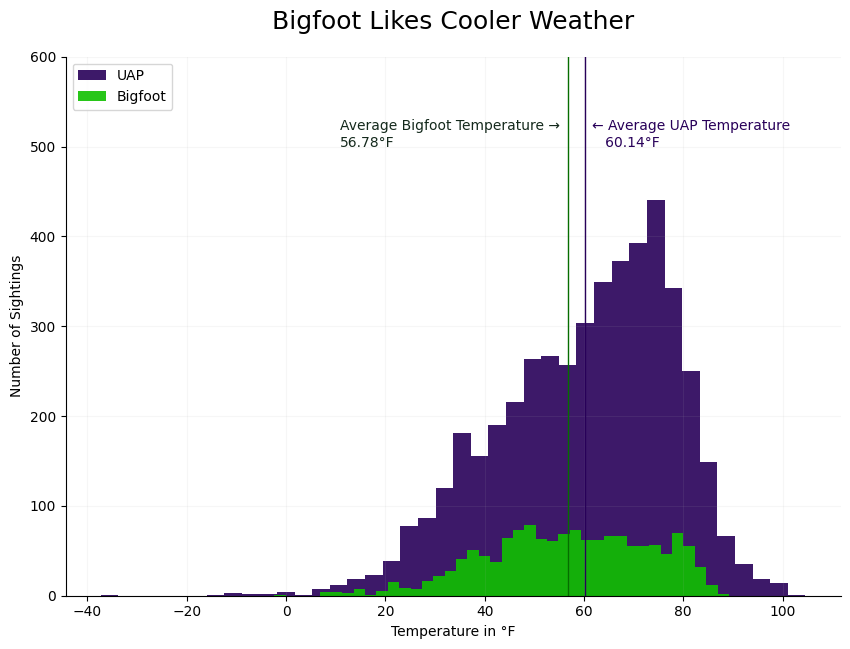

In [98]:
# Compare Air Temperatures of UAP and Bigfoot Sightings

uap_temperature = pd.to_numeric(
    sighting_temp_result[sighting_temp_result['report_type'] == 'UAP']['temperature_f']
    .astype(str).str.replace(r".*/.*", "", regex=True)
)
mean_uap_temperature = uap_temperature.mean().round(2)

bigfoot_temperature = pd.to_numeric(
    sighting_temp_result[sighting_temp_result['report_type'] == 'Bigfoot']['temperature_f']
    .astype(str).str.replace(r".*/.*", "", regex=True)
)
mean_bigfoot_temperature = bigfoot_temperature.mean().round(2)


stellar_night = "#280059"
space_lazer_green = "#10C000"

plt.figure(figsize=(10,7))

plt.hist(uap_temperature, bins=40, alpha=0.9, label='UAP', color=stellar_night)

plt.hist(bigfoot_temperature, bins=40, alpha=0.9, label='Bigfoot', color=space_lazer_green)


plt.xlabel("Temperature in °F")
plt.ylabel("Number of Sightings")
plt.title("Bigfoot Likes Cooler Weather", fontsize=18, pad=20)

plt.grid(True, alpha=0.1)

plt.legend(loc="upper left")

ax = plt.gca()

ax.set_ylim(0, 600)

ax.axvline(mean_uap_temperature, linewidth=1, color=stellar_night)
ax.text(mean_uap_temperature + 1.5, 500,
        f"← Average UAP Temperature\n   {mean_uap_temperature}°F",
        color=stellar_night)

ax.axvline(mean_bigfoot_temperature, linewidth=1, color="#056D00")
ax.text(mean_bigfoot_temperature - 46, 500,
        f"Average Bigfoot Temperature →   \n{mean_bigfoot_temperature}°F",
        color="#14291c")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [99]:
# Compare Cloud Cover Of UAP and Bigfoot Sightings
# Since There Are Fewer Bigfoot Reports, We Will Use Percentages 

# Bigfoot percentages by 10-point cloud-cover bins
# UAP percentages by the same bins
# Select with both CTEs side-by-side

cloud_cover_query = """

WITH 


bigfoot_bins AS (
    SELECT
        CASE
            WHEN cloud_cover >= 0  AND cloud_cover < 10  THEN '0-10'
            WHEN cloud_cover >= 10 AND cloud_cover < 20  THEN '10-20'
            WHEN cloud_cover >= 20 AND cloud_cover < 30  THEN '20-30'
            WHEN cloud_cover >= 30 AND cloud_cover < 40  THEN '30-40'
            WHEN cloud_cover >= 40 AND cloud_cover < 50  THEN '40-50'
            WHEN cloud_cover >= 50 AND cloud_cover < 60  THEN '50-60'
            WHEN cloud_cover >= 60 AND cloud_cover < 70  THEN '60-70'
            WHEN cloud_cover >= 70 AND cloud_cover < 80  THEN '70-80'
            WHEN cloud_cover >= 80 AND cloud_cover < 90  THEN '80-90'
            WHEN cloud_cover >= 90 AND cloud_cover <= 100 THEN '90-100'
            ELSE 'out-of-range'
        END AS cloud_range,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS bigfoot_pct
    FROM bigfoot_weather
    WHERE cloud_cover BETWEEN 0 AND 100          -- safety filter
    GROUP BY 1
),


uap_bins AS (
    SELECT
        CASE
            WHEN w.cloud_cover >= 0  AND w.cloud_cover < 10  THEN '0-10'
            WHEN w.cloud_cover >= 10 AND w.cloud_cover < 20  THEN '10-20'
            WHEN w.cloud_cover >= 20 AND w.cloud_cover < 30  THEN '20-30'
            WHEN w.cloud_cover >= 30 AND w.cloud_cover < 40  THEN '30-40'
            WHEN w.cloud_cover >= 40 AND w.cloud_cover < 50  THEN '40-50'
            WHEN w.cloud_cover >= 50 AND w.cloud_cover < 60  THEN '50-60'
            WHEN w.cloud_cover >= 60 AND w.cloud_cover < 70  THEN '60-70'
            WHEN w.cloud_cover >= 70 AND w.cloud_cover < 80  THEN '70-80'
            WHEN w.cloud_cover >= 80 AND w.cloud_cover < 90  THEN '80-90'
            WHEN w.cloud_cover >= 90 AND w.cloud_cover <= 100 THEN '90-100'
            ELSE 'out-of-range'
        END AS cloud_range,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS uap_pct
    FROM us_uap_2011_weather w
    INNER JOIN uap_reports u ON w.uap_id = u.uap_id
    WHERE w.cloud_cover BETWEEN 0 AND 100
    GROUP BY 1
)


SELECT
    COALESCE(b.cloud_range, u.cloud_range) AS cloud_range,
    COALESCE(b.bigfoot_pct, 0)             AS bigfoot_pct,
    COALESCE(u.uap_pct, 0)                 AS uap_pct
FROM bigfoot_bins b
FULL OUTER JOIN uap_bins u 
    ON b.cloud_range = u.cloud_range
ORDER BY 
    CASE COALESCE(b.cloud_range, u.cloud_range)
        WHEN '0-10'   THEN 1
        WHEN '10-20'  THEN 2
        WHEN '20-30'  THEN 3
        WHEN '30-40'  THEN 4
        WHEN '40-50'  THEN 5
        WHEN '50-60'  THEN 6
        WHEN '60-70'  THEN 7
        WHEN '70-80'  THEN 8
        WHEN '80-90'  THEN 9
        WHEN '90-100' THEN 10
        ELSE 11
    END;


"""

cloud_cover_result = pd.read_sql(cloud_cover_query, connection)
cloud_cover_result



,cloud_range,bigfoot_pct,uap_pct
0,0-10,10.31,41.56
1,10-20,5.37,7.50
2,20-30,7.63,5.77
3,30-40,9.39,4.89
4,40-50,8.69,3.96
5,50-60,8.76,4.01
6,60-70,8.55,3.84
7,70-80,10.17,3.49
8,80-90,9.68,4.63
9,90-100,21.47,20.36


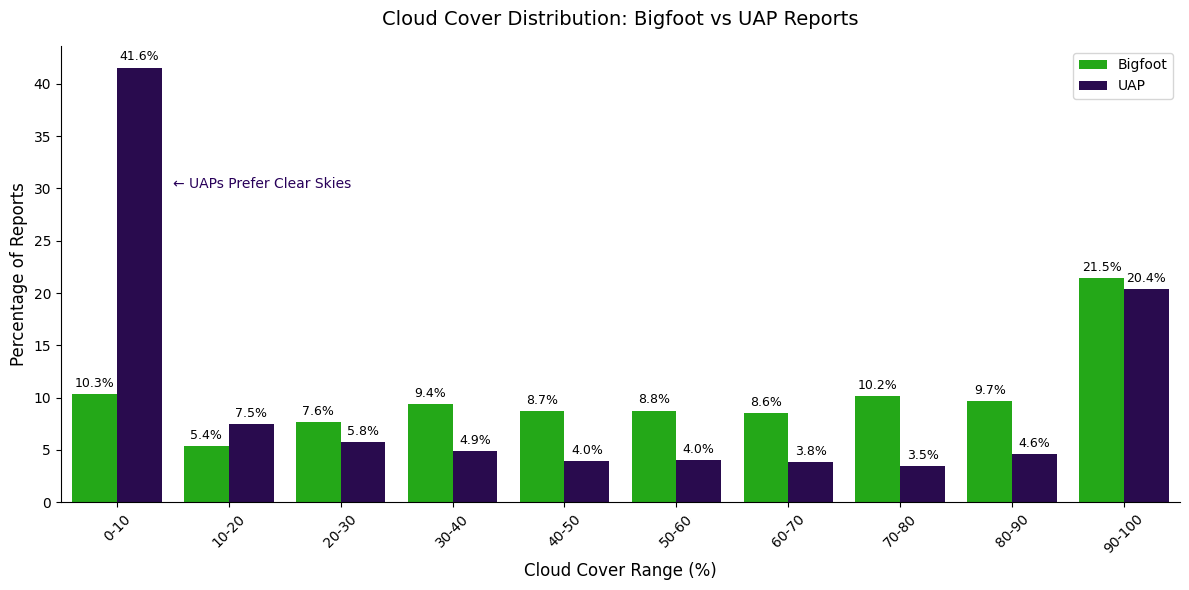

In [100]:
# Compare Cloud Cover of UAP and Bigfoot Sightings

# Melt First

cloud_cover_long_df = cloud_cover_result.melt(
    id_vars='cloud_range',
    value_vars=['bigfoot_pct', 'uap_pct'],
    var_name='Type',
    value_name='Percentage'  
)


cloud_cover_long_df['Type'] = cloud_cover_long_df['Type'].replace({
    'bigfoot_pct': 'Bigfoot',
    'uap_pct': 'UAP'
})

# SNS Grouped Barplot 

stellar_night = "#280059"
space_lazer_green = "#10C000"

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=cloud_cover_long_df,
    x='cloud_range',
    y='Percentage',
    hue='Type',
    palette=[space_lazer_green, stellar_night],  
    errorbar=None
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text( 0.5, 30, f"← UAPs Prefer Clear Skies", color=stellar_night)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)

plt.title('Cloud Cover Distribution: Bigfoot vs UAP Reports', fontsize=14, pad=15)
plt.xlabel('Cloud Cover Range (%)', fontsize=12)
plt.ylabel('Percentage of Reports', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='')
plt.tight_layout()
plt.show()



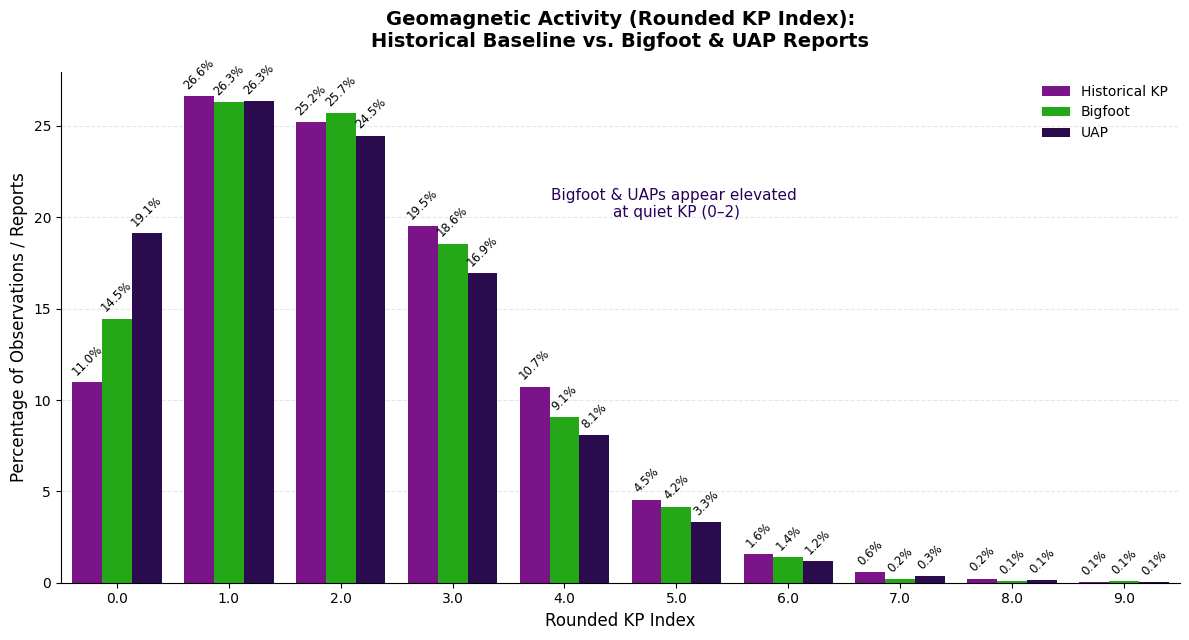

In [101]:
# Historical KP vs Bigfoot & UAP Report Conditions

kp_result_long_df = kp_index_pct_result.copy().melt(
    id_vars='kp_index',
    value_vars=['kp_pct', 'bigfoot_kp_pct', 'uap_kp_pct'],
    var_name='Type',
    value_name='Percentage'
)

kp_result_long_df['Type'] = kp_result_long_df['Type'].replace({
    'kp_pct': 'Historical KP',
    'bigfoot_kp_pct': 'Bigfoot',
    'uap_kp_pct': 'UAP'
})


hue_order = ['Historical KP', 'Bigfoot', 'UAP']

stellar_night   = "#280059"   
space_lazer_green = "#10C000" 
solar_flare     = "#8a009c"   

plt.figure(figsize=(12, 6.5))
ax = sns.barplot(
    data=kp_result_long_df,
    x='kp_index',
    y='Percentage',
    hue='Type',
    hue_order=hue_order,
    palette=[solar_flare, space_lazer_green, stellar_night],
    errorbar=None,
    width=0.8          
)

# Clean spines + subtle grid
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# Annotation 
ax.text( 5, 20,
    "Bigfoot & UAPs appear elevated \nat quiet KP (0–2)",
    fontsize=11,
    color=stellar_night,
    ha='center',
    fontweight='medium'
)

# Bar labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=8.5, rotation=45)


plt.title('Geomagnetic Activity (Rounded KP Index):\nHistorical Baseline vs. Bigfoot & UAP Reports',
          fontsize=14, pad=18, fontweight='semibold')
plt.xlabel('Rounded KP Index', fontsize=12)
plt.ylabel('Percentage of Observations / Reports', fontsize=12)
plt.xticks(rotation=0)          
plt.legend(title='', frameon=False, loc='upper right')

plt.tight_layout()
plt.show()